# VIX Weekend Arithmetic — a quantitative teardown 🔬
### Day-of-week table with HAC inference · label-shuffle placebo · the variance-day-count model race and the implied weekend fraction · decade + calendar-gap robustness · the VIXY leak test with costs · a planted-*f* synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ETP_harvest%3F: Busted](https://img.shields.io/badge/ETP_harvest%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is *mechanical*: the VIX's 30-**calendar**-day window vs trading-day variance accrual forces a day-of-week drift into the index. Mechanical claims still owe the tape a number — so we measure the seesaw, race it against the model's predicted magnitude, and test the only version of it anyone could trade.

> ⚠️ **Data note.** ^VIX daily closes 1990-01-02 → 2026-06-30 (9,190 changes; a single continuously published index — no survivorship on the Signal axis) + VIXY total-return closes 2011+ for the third axis (the surviving continuous-tape VXX-equivalent, named here). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `63115cff08dc` / `829eafeefcc4`, as-of 2026-06-30).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
WD = ["Mon", "Tue", "Wed", "Thu", "Fri"]

from vix_weekend_arithmetic import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX = data.load_vix()
    VIXY = data.load_vixy()
    D = st.dlog_pct(VIX)
else:
    VIX = VIXY = D = None
print("real ^VIX/VIXY cache present:", HAVE_REAL,
      "| daily changes:", (0 if D is None else len(D)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1990-01-03', 'end': '2026-06-30', 'n_days': 9190, 'table': [('Mon', 1.805, 10.25, 1733), ('Tue', -0.158, -1.05, 1886), ('Wed', -0.564, -3.82, 1883), ('Thu', 0.013, 0.09, 1849), ('Fri', -0.977, -6.02, 1839)], 'mon_mean': 1.805, 'fri_mean': -0.977, 'spread': 2.783, 'welch_t': 11.61, 'hac_t': 11.19, 'hac_mon_t': 10.23, 'hac_fri_t': -3.96, 'p_placebo': '< 1/20,000', 'race': [('Mon', 4.77, 1.81, 1.53), ('Tue', 0.0, -0.16, 0.0), ('Wed', 0.0, -0.56, 0.0), ('Thu', -2.33, 0.01, -0.76), ('Fri', -2.44, -0.98, -0.77)], 'f_implied': 0.597, 'fit_rmse': 0.46, 'decades': [('1990-1999', 2.345, -1.12, 3.464, 8.77), ('2000-2009', 1.856, -0.593, 2.449, 6.63), ('2010-2019', 1.565, -1.217, 2.781, 5.2), ('2020-2026', 1.247, -0.981, 2.229, 3.34)], 'gap_post': 2.067, 'gap_pre': -0.997, 'gap_mid': -0.379, 'n_post': 1904, 'n_pre': 1904, 'gap_t_post_pre': 13.21, 'gap_t_post_mid': 12.83, 'vixy_mon': -0.324, 'vixy_mon_t': -1.72, 'vixy_rest': -0.136, 'vixy_welch': -0.92, 'vix_mon_matched': 1.626, 'n_weekends': 728, 'vixy_years': 15.5, 'trades_yr': 47, 'harvest': [(2.0, -15.2, -17.1), (5.0, -15.2, -19.9), (10.0, -15.2, -24.6)], 'syn': [(1.0, -0.111, -0.63, -0.64, 1.0), (0.3, 4.342, 24.49, 25.09, 0.308)], 'fp_vix': '63115cff08dc', 'fp_vixy': '829eafeefcc4', 'asof': '2026-06-30'}


real ^VIX/VIXY cache present: True | daily changes: 9190


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Mon **+1.805%/day** vs Fri **-0.977%/day**; spread **+2.783%/day**, Welch **t = 11.61**, Newey-West(10) **t = 11.19**, placebo **p < 1/20,000**; t ≥ 3.3 in every decade; calendar-gap cut t = 13.21. Direction = the arithmetic's (folk version is sign-flipped). |
| **Tradability** | `MIRAGE` | Index untradable; VIXY weekend mean **-0.324%** (wrong direction) vs index **+1.626%**; harvest = **-15.2%/yr gross**, **-19.9%/yr net** at 5 bps. |
| **ETP harvest?** | `BUSTED` | 728 weekends / 15.5 yrs: Monday-vs-rest Welch **t = -0.92**, negative mean. |

> 💡 In plain words: the seesaw is as real and as mechanical as calendar effects get — and precisely because it is mechanical and public, no tradable instrument pays it.

## 1 · The claim, steelmanned

VIX² is the (strike-integrated) risk-neutral expected variance of the S&P 500 over the next 30 **calendar** days, annualized in calendar time. Suppose variance accrues at rate $\sigma^2$ per **trading** day and $f\sigma^2$ per weekend day. The window quoted on weekday $d$ holds $N_T(d)$ trading and $N_W(d)$ weekend days — (22, 8) Mon–Wed, (21, 9) Thu, **(20, 10) Fri** — so

$$\mathrm{VIX}(d) \;\propto\; \sqrt{N_{\mathrm{eff}}(d)/30},\qquad N_{\mathrm{eff}}(d) = N_T(d) + f\,N_W(d),$$

and the pure-arithmetic close-to-close change landing on weekday $d$ is $50\,\ln\!\big(N_{\mathrm{eff}}(d)/N_{\mathrm{eff}}(d\!-\!1)\big)$ percent.

- **H₁ (the seesaw exists).** Mean Δln VIX by weekday shows the model's pattern: down into Thu/Fri, up on Monday. *(Note the folk version quotes the sign backwards — the model itself is unambiguous.)*
- **H₂ (it's the arithmetic).** The magnitude matches the model for some economically sensible $f\in[0,1]$, stable across decades, and follows *calendar gaps* (holidays), not weekday labels.
- **H₃ (it's harvestable).** A tradable VIX claim (VIXY) inherits the Monday pop net of carry and costs.

We find **H₁ decisively supported** (HAC t ≈ 11), **H₂ supported at ~40% amplitude** (implied f ≈ 0.6 — a partial weekend discount, consistent with Jones-Shemesh option pricing), **H₃ rejected outright** (the ETP's weekend mean is *negative*).

## 2 · So what? — what rides on each answer

If H₁–H₂ hold, every day-of-week reading of the VIX (Monday "spike" headlines, Friday "complacency" pieces, weekday-conditioned vol signals) needs a mechanical correction of order **1–2%/day** — enormous by calendar-anomaly standards. If H₃ held, there'd be a ~47-trades/yr harvest; the desk's prior (from [375-vxx-roll-decay](../../375-vxx-roll-decay/)) is that futures anticipate the formula and the ETP's roll bleed (~−15%/yr) swamps whatever is left. The inference bar: autocorrelation-robust **t ≥ 2 on the real tape** for the Signal stamp; the synthetic control is machinery proof only, never market evidence.

## 3 · How we'd know — the protocol

- **Tape.** ^VIX closes 1990-01-03 → 2026-06-30 (9,190 daily changes); unit = Δln VIX in % (the level ranges 9→83, so log changes).
- **Day-of-week table.** Mean by the weekday the close lands on; one-sample t per weekday (within-weekday observations are ~1 week apart).
- **Headline contrast.** Monday vs Friday: Welch t on the groups **and** a Newey-West(10) t on the Mon−Fri contrast from the dummy regression $d_t = a + b\,\mathbf{1}_{Mon} + c\,\mathbf{1}_{Fri} + e_t$ (Δln VIX is serially correlated; HAC is the robust statistic).
- **Placebo.** 20,000 seeded reshuffles of the Mon/Fri tags; p = P[shuffled spread ≥ observed].
- **The race.** Fit the single parameter f by least squares over the 5 (demeaned) weekday means; report the implied weekend fraction and the fit residual.
- **Robustness.** By decade; and by *calendar gap* (post-gap = previous close ≥ 3 calendar days back; pre-gap = next close ≥ 3 days ahead — catches holiday weekends; the exchange calendar is public and known in advance).
- **Third axis.** VIXY total-return closes 2011+: Monday(-over-weekend) return vs other days (Welch t) + the literal Friday-close→Monday-close hold, one round trip per weekend at 2/5/10 bps one-way. Entry at Friday's close on a calendar known in advance = the one documented execution lag.
- **Positive control.** Synthetic log-AR(1) vol quoted through the arithmetic with a planted f: the null (f = 1) must stay silent; a planted f = 0.3 must be recovered.

## 4 · The teardown

### 4a · The day-of-week table and the HAC contrast

Mean Δln VIX by weekday with one-sample t's, then the Monday-minus-Friday contrast with Welch and Newey-West(10) statistics, and the label-shuffle placebo (4,000 draws in this cell for speed; the canonical 20,000-draw run in `verify.py` gives the quoted p).

  Mon: +1.805%/day  t = +10.25  (n=1,733)
  Tue: -0.158%/day  t = -1.05  (n=1,886)
  Wed: -0.564%/day  t = -3.82  (n=1,883)
  Thu: +0.013%/day  t = +0.09  (n=1,849)
  Fri: -0.977%/day  t = -6.02  (n=1,839)



  Mon-Fri spread +2.783%/day  Welch t=+11.61  NW(10) t=+11.19  placebo p=0.0000 (4k draws)


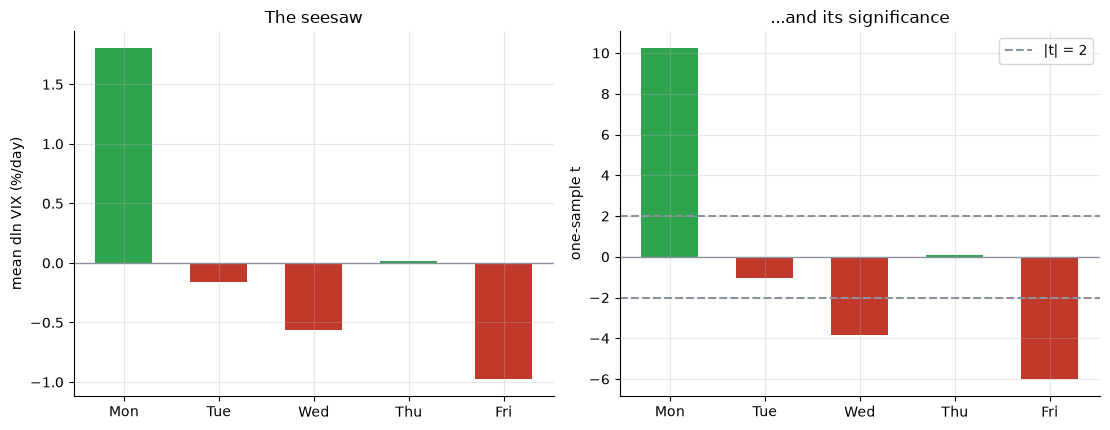

In [2]:
if HAVE_REAL:
    tbl = st.weekday_table(D)
    for r in tbl:
        print(f"  {r['weekday']}: {r['mean_pct']:+.3f}%/day  t = {r['t']:+.2f}  (n={r['n']:,})")
    c = st.mon_fri_contrast(D, lags=10)
    pl = st.placebo_spread(D, n_draws=4000, seed=609)
    print(f"\n  Mon-Fri spread {c['spread']:+.3f}%/day  Welch t={c['welch_t']:+.2f}  "
          f"NW(10) t={c['hac_t']:+.2f}  placebo p={pl['p_value']:.4f} (4k draws)")
    means = [r['mean_pct'] for r in tbl]; tvals = [r['t'] for r in tbl]
else:
    means = [r[1] for r in R['table']]; tvals = [r[2] for r in R['table']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
cols = [GREEN if m > 0 else RED for m in means]
a1.bar(WD, means, color=cols, width=.6); a1.axhline(0, c=GREY, lw=1)
a1.set_ylabel('mean dln VIX (%/day)'); a1.set_title('The seesaw')
a2.bar(WD, tvals, color=cols, width=.6); a2.axhline(0, c=GREY, lw=1)
a2.axhline(2, ls='--', c=GREY); a2.axhline(-2, ls='--', c=GREY, label='|t| = 2')
a2.set_ylabel('one-sample t'); a2.set_title('...and its significance'); a2.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: Monday **+1.80%** (t = +10.2) and Friday **-0.98%** (t = -6.0) are both individually massive; the Mon−Fri contrast is **+2.78%/day** at Welch **t = 11.6** / NW(10) **t = 11.2** with placebo **p < 1/20,000**. The desk bar is t ≥ 2; this clears it five times over. Note Wednesday also prints negative (−0.56%) — the tape spreads the mark-down across the back half of the week a bit differently than the stylized model (see 4b).

### 4b · The arithmetic race — magnitude vs the day-count model

The model's one free parameter is the weekend variance fraction f. Fit it by least squares over the five weekday means and compare the three profiles: full arithmetic (f = 0), the tape, and the model at the fitted f.

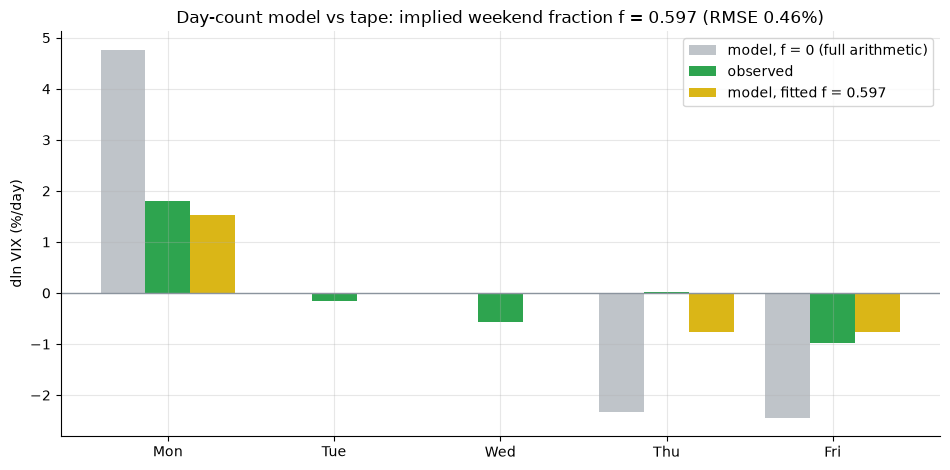

implied f = 0.597   fit RMSE = 0.46%/day


In [3]:
if HAVE_REAL:
    imp = st.implied_weekend_fraction(D)
    obs = [imp['obs'][k] for k in range(5)]
    full = [imp['model_full_arithmetic'][k] for k in range(5)]
    fit = [imp['model_at_fit'][k] for k in range(5)]
    f_hat, rmse = imp['f'], imp['rmse_pct']
else:
    obs = [r[2] for r in R['race']]; full = [r[1] for r in R['race']]
    fit = [r[3] for r in R['race']]; f_hat, rmse = R['f_implied'], R['fit_rmse']
x = np.arange(5); w = 0.27
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.bar(x - w, full, w, color=GREY, alpha=.55, label='model, f = 0 (full arithmetic)')
ax.bar(x,     obs,  w, color=GREEN, label='observed')
ax.bar(x + w, fit,  w, color=AMBER, label=f'model, fitted f = {f_hat:.3f}')
ax.set_xticks(x); ax.set_xticklabels(WD); ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('dln VIX (%/day)')
ax.set_title(f'Day-count model vs tape: implied weekend fraction f = {f_hat:.3f} (RMSE {rmse:.2f}%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'implied f = {f_hat:.3f}   fit RMSE = {rmse:.2f}%/day')

> 💡 In plain words: the tape runs the model's shape at **~40%** of the zero-weekend-variance amplitude — the fitted **f = 0.597** says option markets price a weekend day at **~60%** of a trading day's variance. Two honest caveats: (i) realized weekend variance is far *lower* than 60% of a trading day (French-Roll), so the market under-discounts weekends — exactly Jones-Shemesh's option-mispricing result; (ii) the fit is imperfect (RMSE 0.46%/day): the tape puts more mark-down on Wednesday and less on Thursday than the stylized week. The seesaw is arithmetic × a behavioral weekend discount, not a clean law.

### 4c · Robustness — decades and calendar gaps

A mechanical effect must show up in every regime and must follow *market closures*, not the weekday label. Decade-by-decade Monday-vs-Friday, then the gap cut (post-gap = previous close ≥ 3 calendar days back; pre-gap = next close ≥ 3 ahead — holiday weekends included).

gap cut: post +2.067% (n=1,904)  mid -0.379%  pre -0.997% (n=1,904)  post-vs-pre Welch t = +13.21


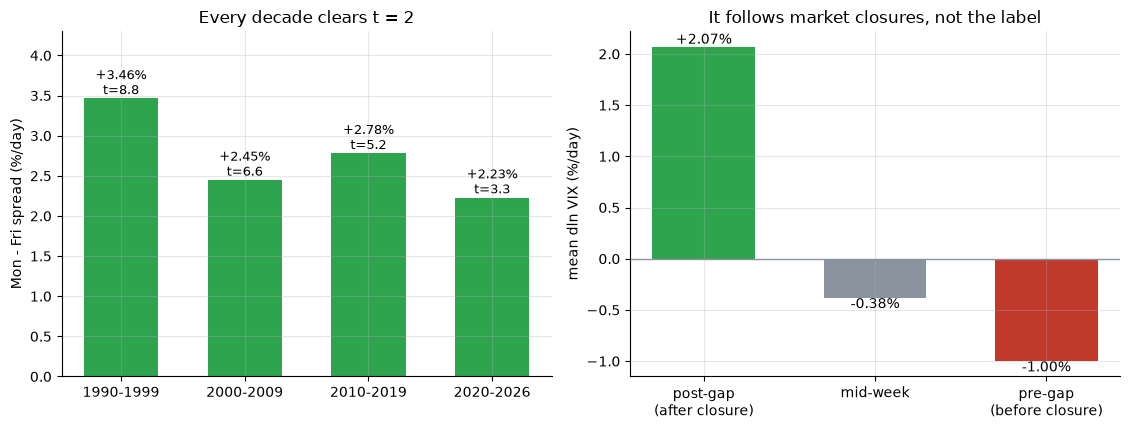

In [4]:
if HAVE_REAL:
    dec = st.by_decade(D)
    labs = [r['decade'] for r in dec]; sprd = [r['spread'] for r in dec]
    wt = [r['welch_t'] for r in dec]
    g = st.gap_table(D)
    gaps = [g['post_mean'], g['mid_mean'], g['pre_mean']]
    print(f"gap cut: post {g['post_mean']:+.3f}% (n={g['n_post']:,})  mid "
          f"{g['mid_mean']:+.3f}%  pre {g['pre_mean']:+.3f}% (n={g['n_pre']:,})  "
          f"post-vs-pre Welch t = {g['welch_t_post_vs_pre']:+.2f}")
else:
    labs = [r[0] for r in R['decades']]; sprd = [r[3] for r in R['decades']]
    wt = [r[4] for r in R['decades']]
    gaps = [R['gap_post'], R['gap_mid'], R['gap_pre']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(labs, sprd, color=GREEN, width=.6)
for i, (s, t) in enumerate(zip(sprd, wt)):
    a1.annotate(f'{s:+.2f}%\nt={t:.1f}', (i, s), ha='center', va='bottom', fontsize=9)
a1.set_ylabel('Mon - Fri spread (%/day)'); a1.set_ylim(0, 4.3)
a1.set_title('Every decade clears t = 2')
a2.bar(['post-gap\n(after closure)', 'mid-week', 'pre-gap\n(before closure)'], gaps,
       color=[GREEN, GREY, RED], width=.6)
for i, v in enumerate(gaps):
    a2.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top')
a2.axhline(0, c=GREY, lw=1)
a2.set_ylabel('mean dln VIX (%/day)'); a2.set_title('It follows market closures, not the label')
plt.tight_layout(); plt.show()

> 💡 In plain words: the spread runs **+3.5% → +2.2%** across the four decades (t = 8.8 → 3.3) — a mild narrowing, never a disappearance. And cut by *calendar gap* instead of weekday, post-closure days print **+2.07%** vs **-1.00%** pre-closure (Welch t = 13.2) — holiday weekends behave exactly like ordinary ones. That is the mechanism's signature: it's the closure entering and leaving the 30-day window.

### 4d · The leak test — can VIXY harvest the pop? (third axis)

The index is a formula; the tradable claim is a short-term VIX-futures ETP. Buy Friday's close, sell Monday's close, ~47 weekends/yr, one round trip per weekend at 2/5/10 bps one-way. If the futures anticipate the arithmetic, the ETP's weekend return should show nothing but its usual roll bleed.

VIXY Monday mean -0.324% (t=-1.72)  vs other days -0.136%   Welch t = -0.92


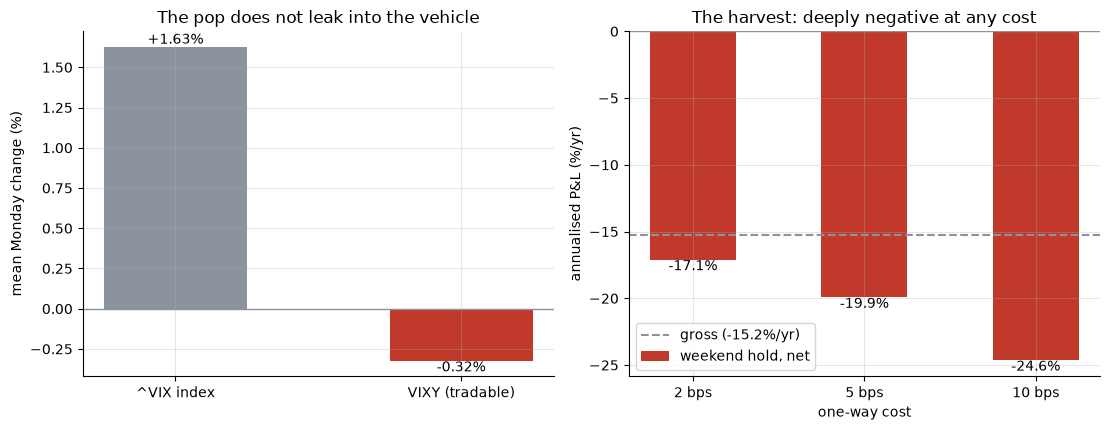

In [5]:
if HAVE_REAL:
    v = st.vixy_weekend(VIXY, VIX, cost_bps=5.0)
    idx_mon, etp_mon = v['vix_mon_mean_pct'], v['mon_mean_pct']
    net = [st.vixy_weekend(VIXY, VIX, cost_bps=cb)['net_ann_pct'] for cb in (2.0, 5.0, 10.0)]
    gross = v['gross_ann_pct']
    print(f"VIXY Monday mean {etp_mon:+.3f}% (t={v['mon_t']:+.2f})  vs other days "
          f"{v['rest_mean_pct']:+.3f}%   Welch t = {v['welch_t']:+.2f}")
else:
    idx_mon, etp_mon = R['vix_mon_matched'], R['vixy_mon']
    net = [h[2] for h in R['harvest']]; gross = R['harvest'][0][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['^VIX index', 'VIXY (tradable)'], [idx_mon, etp_mon], color=[GREY, RED], width=.5)
for i, v_ in enumerate([idx_mon, etp_mon]):
    a1.annotate(f'{v_:+.2f}%', (i, v_), ha='center', va='bottom' if v_ > 0 else 'top')
a1.axhline(0, c=GREY, lw=1); a1.set_ylabel('mean Monday change (%)')
a1.set_title('The pop does not leak into the vehicle')
a2.bar(['2 bps', '5 bps', '10 bps'], net, color=RED, width=.5, label='weekend hold, net')
a2.axhline(gross, ls='--', c=GREY, label=f'gross ({gross:.1f}%/yr)')
for i, v_ in enumerate(net): a2.annotate(f'{v_:.1f}%', (i, v_), ha='center', va='top')
a2.axhline(0, c=GREY, lw=1); a2.set_xlabel('one-way cost')
a2.set_ylabel('annualised P&L (%/yr)'); a2.set_title('The harvest: deeply negative at any cost')
a2.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: over the matched 2011–2026 window the **index** pops **+1.63%** on Mondays while **VIXY loses -0.32%** — the *wrong direction*, and statistically just its ordinary decay (Monday-vs-rest Welch t = -0.92). The literal harvest bleeds **-15.2%/yr gross** and **-19.9%/yr net** at 5 bps. Futures price the forward VIX; a deterministic dip in the spot formula is already in Friday's futures price. **BUSTED** — and the Tradability stamp is a clean **MIRAGE**.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic log-AR(1) "true vol" quoted through the day-count arithmetic with a planted weekend fraction. f = 1.0 is the null (weekends count fully — no weekday pattern): the machinery must stay silent. f = 0.3 plants a big seesaw: the machinery must light up *and* recover f.

planted f=1.0: spread -0.111%/day  Welch t=-0.63  NW t=-0.64  recovered f=1.000


planted f=0.3: spread +4.342%/day  Welch t=+24.49  NW t=+25.09  recovered f=0.308


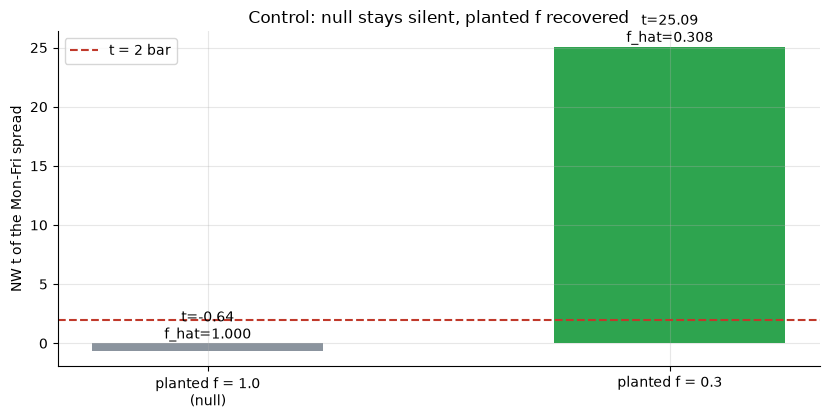

In [6]:
res = []
for f in (1.0, 0.3):
    syn = data.synthetic_tape(f=f, seed=609)
    ds = st.dlog_pct(syn)
    cs = st.mon_fri_contrast(ds, lags=10)
    im = st.implied_weekend_fraction(ds)
    res.append((f, cs['spread'], cs['welch_t'], cs['hac_t'], im['f']))
    print(f'planted f={f:.1f}: spread {cs["spread"]:+.3f}%/day  Welch t={cs["welch_t"]:+.2f}  '
          f'NW t={cs["hac_t"]:+.2f}  recovered f={im["f"]:.3f}')
fig, ax = plt.subplots(figsize=(8.4, 4.3))
labels = [f'planted f = {r[0]:.1f}\n(null)' if r[0] == 1.0 else f'planted f = {r[0]:.1f}' for r in res]
ax.bar(labels, [r[3] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res):
    ax.annotate(f't={r[3]:.2f}\nf_hat={r[4]:.3f}', (i, max(r[3], 0)), ha='center', va='bottom')
ax.set_ylabel('NW t of the Mon-Fri spread')
ax.set_title('Control: null stays silent, planted f recovered')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: with weekends counted fully (the null) the estimator reports t = -0.64 and f = 1.000 — no manufactured significance; with a planted f = 0.3 it reports t = 25.09 and recovers f = 0.308. The machinery is unbiased in both directions, so the real-tape t ≈ 11 and f ≈ 0.60 are genuine measurements. *(A faithful-engine / power check only — never cited to support the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL`** — Mon **+1.805%/day**, Fri **-0.977%/day**, spread **+2.783%/day** at Welch **t = 11.61** / NW(10) **t = 11.19**, placebo **p < 1/20,000**, t ≥ 3.3 in every decade, calendar-gap signature t = 13.2. Direction exactly as the arithmetic predicts (the folk "up-into-Friday" version is sign-flipped). Magnitude = the arithmetic × a partial weekend discount (implied f = 0.597).
- **Tradability `MIRAGE`** — the index is a formula; the tradable claim (VIXY) shows **-0.324%** on the average weekend vs the index's **+1.626%**, and the literal harvest loses **-19.9%/yr net** at 5 bps. Fully anticipated by construction.
- **ETP harvest? `BUSTED`** — 728 weekends, 15.5 years, Welch t = -0.92, wrong sign. The seesaw never leaves the formula.

## 6 · Going further

- **The weekday correction matters for research.** Any signal conditioned on VIX changes (vol-spike triggers, risk-on/off filters) inherits a ±1–2%/day mechanical weekday tilt; de-seasonalize by weekday (or by calendar gap) before interpreting.
- **f is a live behavioral quantity.** Realized weekend variance is ~10–20% of a trading day (French-Roll); the options market prices ~60%. That 40-point wedge is the Jones-Shemesh mispricing, visible in an index formula — a nice teaching bridge from microstructure to macro folklore.
- **Where a real trade *might* hide** is not the spot formula but instruments with imperfect calendar handling — deep-weekly options into 3-day holiday weekends, or VIX futures in their final hours. Both are cost- and capacity-hostile; the desk's priors sit in [605-vix-settlement-day](../../605-vix-settlement-day/) and [111-vix-term-structure](../../111-vix-term-structure/).

*The reproducible core is offline and deterministic; methods and sources in [`docs/references.md`](../docs/references.md); frozen numbers in [`docs/results.md`](../docs/results.md).*